In [1]:
%matplotlib ipympl

In [ ]:
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from datetime import date
from scipy.stats.mstats import winsorize
import pandas as pd

In [3]:
start = date(2020, 7, 1)
end = date(2026, 5, 31)

In [4]:
client = ModoEnergyAPIClient(cache_requests=True)

In [83]:
prices_raw = client.get_ercot_prices(date_from=start, date_to=end)

Fetching pages : 0page [00:00, ?page/s]

In [84]:
prices_raw

,hourEnding,repeatedHourFlag,settlementPointName,settlementPointPrice
deliveryDate,,,,
2026-05-31 23:00:00,24,N,LZ_WEST,29.46
2026-05-31 23:00:00,24,N,LZ_SOUTH,27.27
2026-05-31 23:00:00,24,N,LZ_RAYBN,26.84
2026-05-31 23:00:00,24,N,LZ_NORTH,26.85
2026-05-31 23:00:00,24,N,LZ_LCRA,27.33
...,...,...,...,...
2020-07-01 00:00:00,1,N,HB_PAN,7.81
2020-07-01 00:00:00,1,N,HB_NORTH,14.10
2020-07-01 00:00:00,1,N,HB_HUBAVG,13.80


In [86]:
prices = prices_raw  # prices[prices.index > pd.to_datetime(date(2022, 9, 11))]

In [92]:
hub_prices = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
]

In [96]:
plt.clear()
hub_prices.plot()
plt.show()

AttributeError: module 'matplotlib.pyplot' has no attribute 'clear'

In [88]:
hub_prices_winsorized = pd.DataFrame(
    {hub_prices.name: winsorize(hub_prices, limits=[None, 0.1])},
    index=hub_prices.index,
)

In [62]:
arbitrage_opportunity = (
    hub_prices_winsorized.resample("D")
    .agg(lambda d: max(d[d.index.hour == 19].item() - d[d.index.hour == 12].item(), 0))
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
)

<Axes: xlabel='deliveryDate'>

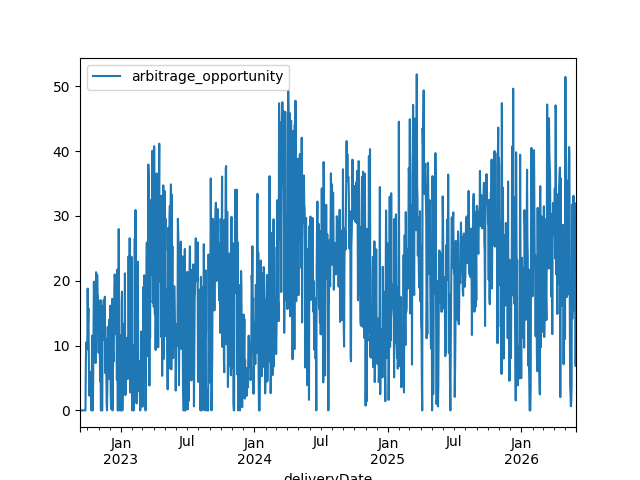

In [63]:
arbitrage_opportunity.plot()

In [64]:
fs = 1.0  # / 168.0
frequencies, psd = periodogram(
    arbitrage_opportunity["arbitrage_opportunity"], fs=fs, scaling="spectrum"
)

Dominant Cycle Period: 1359.0 days
Dominant Cycle Period: 453.0 days
Dominant Cycle Period: 169.9 days
Dominant Cycle Period: 90.6 days
Dominant Cycle Period: 54.4 days
Dominant Cycle Period: 30.2 days
Dominant Cycle Period: 24.3 days
Dominant Cycle Period: 23.0 days
Dominant Cycle Period: 18.1 days
Dominant Cycle Period: 14.5 days
Dominant Cycle Period: 11.9 days
Dominant Cycle Period: 5.9 days
Dominant Cycle Period: 5.4 days
Dominant Cycle Period: 3.5 days
Dominant Cycle Period: 2.7 days


C:\Users\andre\AppData\Local\Temp\ipykernel_25832\351868506.py:4: RuntimeWarning: divide by zero encountered in divide
  periods_in_days = 1 / frequencies


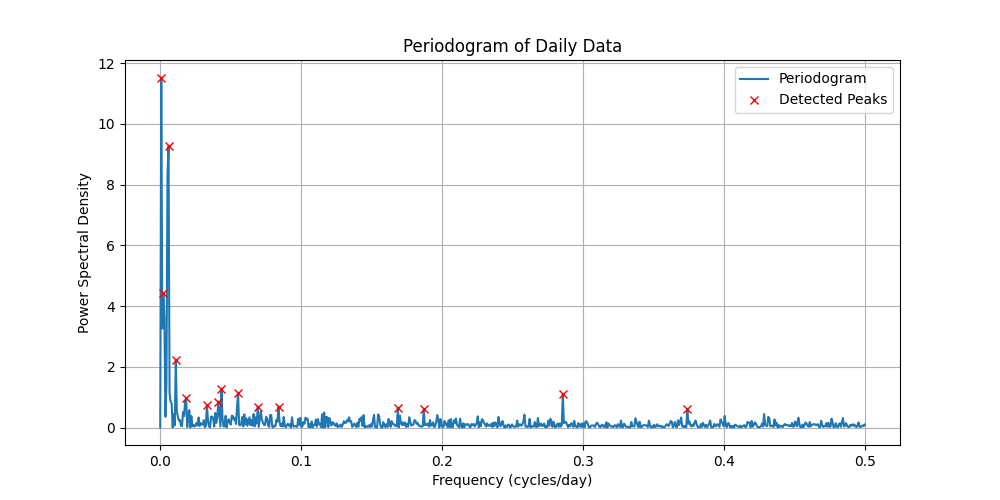

In [66]:
peaks, properties = signal.find_peaks(psd, prominence=np.max(psd) * 0.05)

# 4. Convert frequency to "Period in Days" (Period = 1 / Frequency)
periods_in_days = 1 / frequencies

# Display the detected dominant periods
for peak in peaks:
    print(f"Dominant Cycle Period: {periods_in_days[peak]:.1f} days")

# 5. Plotting the results
plt.figure(figsize=(10, 5))
plt.plot(frequencies, psd, label="Periodogram")
plt.plot(frequencies[peaks], psd[peaks], "x", color="red", label="Detected Peaks")
plt.xlabel("Frequency (cycles/day)")
plt.ylabel("Power Spectral Density")
plt.title("Periodogram of Daily Data")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
frequencies

array([4.62748727e-04, 9.25497455e-04, 1.38824618e-03, ...,
       4.98843128e-01, 4.99305877e-01, 4.99768626e-01], shape=(1080,))

In [56]:
periods_in_days

array([2.16100000e+03, 1.08050000e+03, 7.20333333e+02, ...,
       2.00463822e+00, 2.00278035e+00, 2.00092593e+00], shape=(1080,))

In [67]:
from prophet import Prophet

In [75]:
prophet_data = arbitrage_opportunity.reset_index().rename(
    {"deliveryDate": "ds", "arbitrage_opportunity": "y"}, axis=1
)

In [76]:
prophet_data

,ds,y
0,2022-09-11,0.00
1,2022-09-12,0.00
2,2022-09-13,0.00
3,2022-09-14,0.00
4,2022-09-15,0.00
...,...,...
1354,2026-05-27,32.02
1355,2026-05-28,26.95
1356,2026-05-29,24.26
1357,2026-05-30,6.84


In [77]:
m = Prophet()
m.fit(prophet_data)

16:27:37 - cmdstanpy - INFO - Chain [1] start processing
16:27:37 - cmdstanpy - INFO - Chain [1] done processing


In [79]:
future = m.make_future_dataframe(periods=365)

In [80]:
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
1719,2027-05-27,21.694208,9.018586,33.255359
1720,2027-05-28,20.958205,7.980973,32.283794
1721,2027-05-29,21.356487,9.129142,34.037555
1722,2027-05-30,25.030371,12.820258,36.913542
1723,2027-05-31,21.687474,10.043617,33.773211


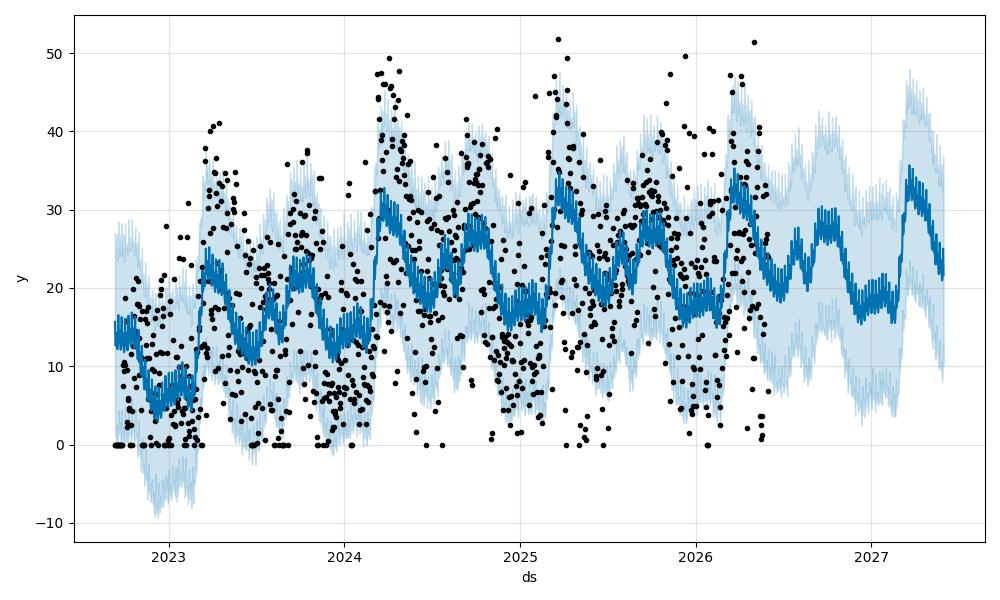

In [81]:
fig1 = m.plot(forecast)

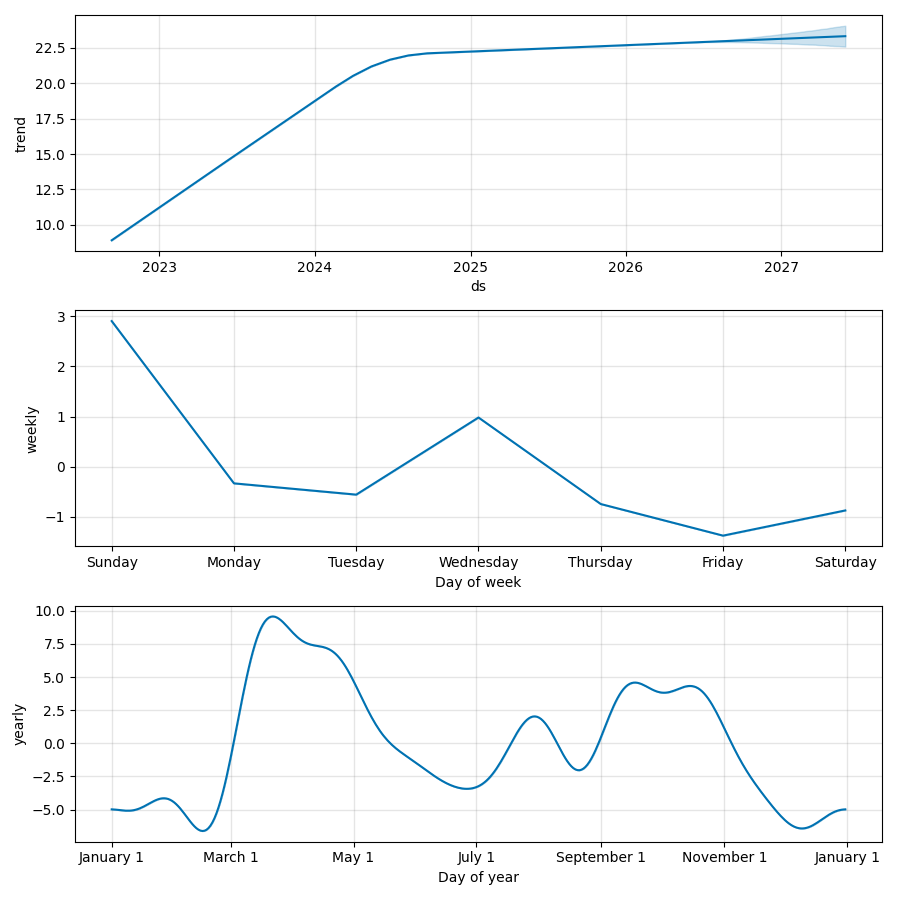

In [82]:
fig2 = m.plot_components(forecast)